# Wind forecast error generalization notebook - aligned with the PV workflow

## Strategy Overview
1. Data source: GEFC2012 wind farm 2 (column wp2), with no nighttime filtering because wind generation is available throughout the day
2. Follow the KDE + Copula workflow in `solar_error_generalization.ipynb` exactly
3. Time window: 48 half-hour steps per period, consistent with the PV workflow
4. Outputs:
   - `data/processed/GEFC2012_temporal_correlated_error_samples.npy`
   - `data/processed/GEFC2012_wind_forecast.npy`

In [1]:
# Import required libraries
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import interpolate
from scipy.special import ndtr
from scipy.stats import gaussian_kde, multivariate_normal, norm

## 1. Data loading and preprocessing

In [2]:
print("=== 1. Data loading and preprocessing ===")

# Load the GEFC2012 wind data
bronze = pd.read_csv('data/raw/GEFC2012_bronze.csv').sort_values('id').reset_index(drop=True)
solution = pd.read_csv('data/raw/GEFC2012_solution.csv').sort_values('id').reset_index(drop=True)

print(f"Original number of rows (bronze): {len(bronze)}")
print(f"Original number of rows (solution): {len(solution)}")

# Use wind farm 2 (`wp2`), consistent with `WT_error_gen.py`
measured = bronze['wp2'].to_numpy()
forecast = solution['wp2'].to_numpy()

print(f"Measured-value range: [{measured.min():.4f}, {measured.max():.4f}]")
print(f"Forecast-value range: [{forecast.min():.4f}, {forecast.max():.4f}]")

=== 1. Data loading and preprocessing ===
Original number of rows (bronze): 7488
Original number of rows (solution): 7488
Measured-value range: [-0.0988, 1.0290]
Forecast-value range: [0.0000, 0.9840]


## 2. Forecast error calculation

In [3]:
print("\n=== 2. Forecast error calculation ===")

# Forecast error = measured value - forecast value (positive means overproduction, negative means underproduction)
forecast_error = measured - forecast

# Normalize forecast error by the standard deviation of measured values, consistent with the PV script
forecast_error_normalized = forecast_error / np.std(measured)

print(f"Error statistics (normalized):")
print(f"  Mean: {np.mean(forecast_error_normalized):.4f}")
print(f"  Std: {np.std(forecast_error_normalized):.4f}")
print(f"  Min: {np.min(forecast_error_normalized):.4f}")
print(f"  Max: {np.max(forecast_error_normalized):.4f}")


=== 2. Forecast error calculation ===
Error statistics (normalized):
  Mean: -0.0131
  Std: 0.6444
  Min: -3.4160
  Max: 3.1054


## 3. Reshape into a time-series structure (strictly following the PV method)

In [4]:
print("\n=== 3. Reshape into a time-series structure ===")

# Each period contains 48 half-hour steps, consistent with the PV workflow
# Note: wind generation has no nighttime zero-output filtering, so reshaping can be applied directly
num_time_points = 48
num_days = len(forecast_error_normalized) // num_time_points

# Trim to complete periods
forecast_error_normalized = forecast_error_normalized[: num_days * num_time_points]
forecast_error_matrix = forecast_error_normalized.reshape(num_days, num_time_points)   # shape: (num_days, 48)

print(f"Error matrix shape: {forecast_error_matrix.shape}")
print(f"  Number of periods (days)  : {num_days}")
print(f"  Time points per period : {num_time_points}")
print(f"  Note: wind generation is available throughout the day, with no nighttime filtering")

# Construct the forecast prototype curve simultaneously (period-wise average, length T)
forecast_matrix = forecast[: num_days * num_time_points].reshape(num_days, num_time_points)
measured_matrix = measured[: num_days * num_time_points].reshape(num_days, num_time_points)
norm_factor = np.max(measured_matrix)
forecast_prototype_normalized = forecast_matrix.mean(axis=0) / norm_factor
print(f"Forecast prototype shape: {forecast_prototype_normalized.shape}  (normalized to [0,1])")


=== 3. Reshape into a time-series structure ===
Error matrix shape: (156, 48)
  Number of periods (days)  : 156
  Time points per period : 48
  Note: wind generation is available throughout the day, with no nighttime filtering
Forecast prototype shape: (48,)  (normalized to [0,1])


## 4. Temporal correlation analysis

In [5]:
print("\n=== 4. Temporal correlation analysis ===")

temp_corr = np.corrcoef(forecast_error_matrix, rowvar=False)
print(f"Temporal-correlation matrix shape: {temp_corr.shape}")


=== 4. Temporal correlation analysis ===
Temporal-correlation matrix shape: (48, 48)


Temporal-correlation heatmap saved: data/wind_error_temporal_correlation.png


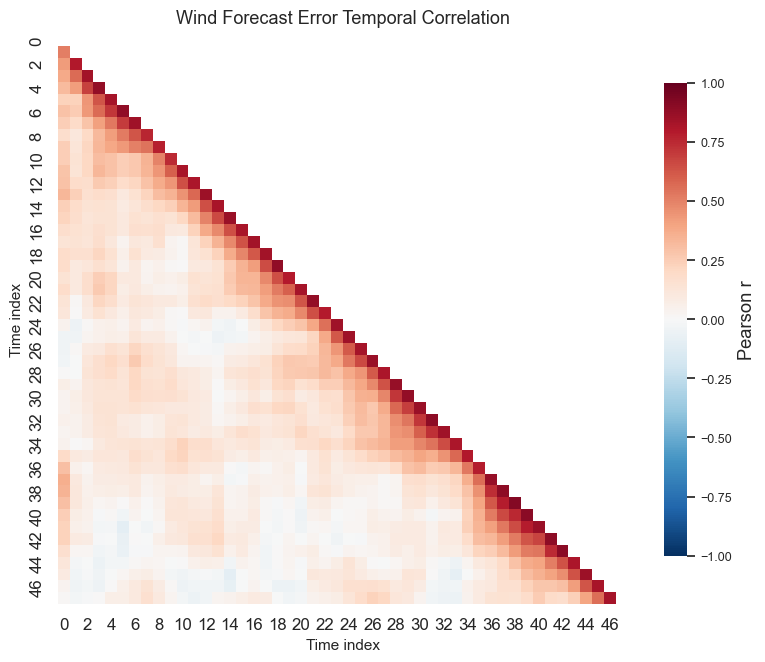

In [6]:
# Visualize the temporal-correlation heatmap in the same style as the PV notebook
sns.set_theme(style='white', font_scale=1.1)
mask_upper = np.triu(np.ones_like(temp_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 7))
hm = sns.heatmap(temp_corr, annot=False, fmt=".2f", mask=mask_upper, ax=ax,
                 cmap='RdBu_r', vmin=-1, vmax=1, square=True,
                 linewidths=0, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
hm.collections[0].colorbar.ax.tick_params(labelsize=9)
ax.set_title('Wind Forecast Error Temporal Correlation', fontsize=13, pad=8)
ax.set_xlabel('Time index', fontsize=11)
ax.set_ylabel('Time index', fontsize=11)
plt.tight_layout()
plt.savefig('data/wind_error_temporal_correlation.png', dpi=300, bbox_inches='tight')
print("Temporal-correlation heatmap saved: data/wind_error_temporal_correlation.png")
plt.show()

## 5. Fit the marginal distribution with KDE

In [7]:
print("\n=== 5. Fit the marginal distribution with KDE ===")

# Flatten the forecast-error data to build the marginal sample set
marginal_error = forecast_error_matrix.flatten()

# Fit the KDE model
kde = gaussian_kde(marginal_error)

# Generate a smooth PDF curve
x = np.linspace(np.min(marginal_error), np.max(marginal_error), 100)
kde_pdf = kde.pdf(x)

# Fit a Gaussian distribution for comparison
mu, std = np.mean(marginal_error), np.std(marginal_error)
p = norm.pdf(x, mu, std)


=== 5. Fit the marginal distribution with KDE ===


Marginal-distribution figure saved: data/wind_error_marginal_distribution.png


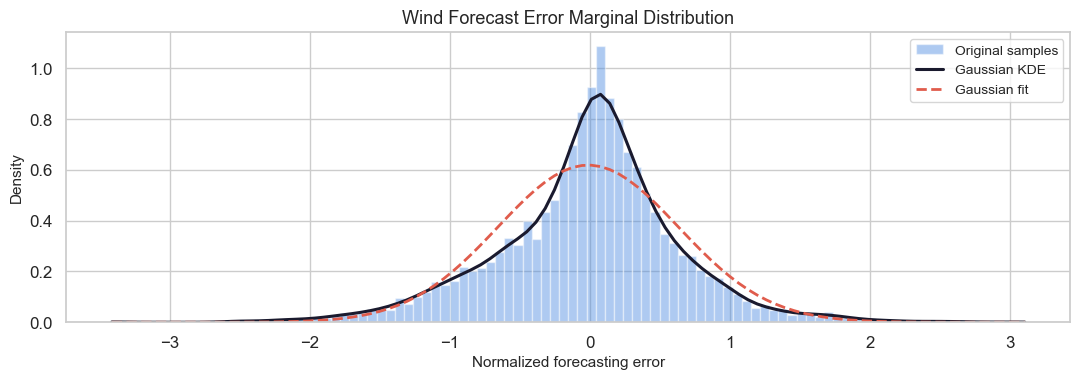

In [8]:
# Visualize the marginal distribution
sns.set_theme(style='whitegrid', font_scale=1.1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(marginal_error, bins=100, alpha=0.45, color='#4C8BE0', label='Original samples', density=True)
ax.plot(x, kde_pdf, color='#1A1A2E', linewidth=2.2, label='Gaussian KDE')
ax.plot(x, p, color='#E05C4C', linewidth=2.0, linestyle='--', label='Gaussian fit')
ax.set_xlabel('Normalized forecasting error', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(frameon=True, fontsize=10)
ax.set_title('Wind Forecast Error Marginal Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('data/wind_error_marginal_distribution.png', dpi=300, bbox_inches='tight')
print("Marginal-distribution figure saved: data/wind_error_marginal_distribution.png")
plt.show()

## 6. Generate temporally correlated samples with a Copula method

In [9]:
print("\n=== 6. Generate temporally correlated samples with a Copula method ===")

# Set the number of generated samples
n_scenario = 200000
print(f"Number of generated scenarios: {n_scenario}")


=== 6. Generate temporally correlated samples with a Copula method ===
Number of generated scenarios: 200000


In [10]:
# 6.1 Generate multivariate Gaussian samples
mvnorm = multivariate_normal(mean=np.zeros(temp_corr.shape[0]), cov=temp_corr)
samples_gaussian = mvnorm.rvs(size=n_scenario, random_state=0)
print(f"Multivariate Gaussian sample shape: {samples_gaussian.shape}")

Multivariate Gaussian sample shape: (200000, 48)


In [11]:
# 6.2 Transform the samples into uniform samples (Gaussian Copula)
norm_dist = norm()
samples_uniform = norm_dist.cdf(samples_gaussian)
print(f"Uniform sample shape: {samples_uniform.shape}")

Uniform sample shape: (200000, 48)


In [12]:
# 6.3 Construct the KDE CDF and inverse CDF in batches to save memory
print("Computing the KDE CDF in batches to reduce memory usage...")

stdev = np.sqrt(kde.covariance)[0, 0]
xmax = np.max(marginal_error)
xmin = np.min(marginal_error)
minmax_dist = xmax - xmin

# Generate the x-axis grid for the CDF
xx = np.linspace(xmin - 0. * minmax_dist, xmax + 0. * minmax_dist, 5000)

# Estimate the KDE CDF in batches to save memory
n_resample = 50000
n = kde.resample(n_resample, seed=0).flatten()

# Compute the CDF in batches
batch_size = 1000
kde_cdf = np.zeros(len(xx))
for i in range(0, len(xx), batch_size):
    batch_end = min(i + batch_size, len(xx))
    xx_batch = xx[i:batch_end]
    kde_cdf[i:batch_end] = ndtr(np.subtract.outer(xx_batch, n) / stdev).mean(axis=1)
    if (i // batch_size) % 5 == 0:
        print(f"  Progress: {batch_end}/{len(xx)}")

print("KDE CDF computation completed")

Computing the KDE CDF in batches to reduce memory usage...
  Progress: 1000/5000
KDE CDF computation completed


In [13]:
# Construct the inverse CDF function
kde_cdf_inv_func = interpolate.interp1d(kde_cdf, xx, kind='cubic',
                                        bounds_error=False, fill_value='extrapolate')

In [14]:
# 6.4 Generate the final temporally correlated KDE samples
samples_kde_corr = np.vstack([kde_cdf_inv_func(samples_uniform[:, i])
                               for i in range(temp_corr.shape[0])]).T
print(f"Final temporally correlated sample shape: {samples_kde_corr.shape}")

Final temporally correlated sample shape: (200000, 48)


## 7. Validate the generated samples


=== 7. Validate the generated samples ===
Sample-comparison figure saved: data/wind_error_comparison.png


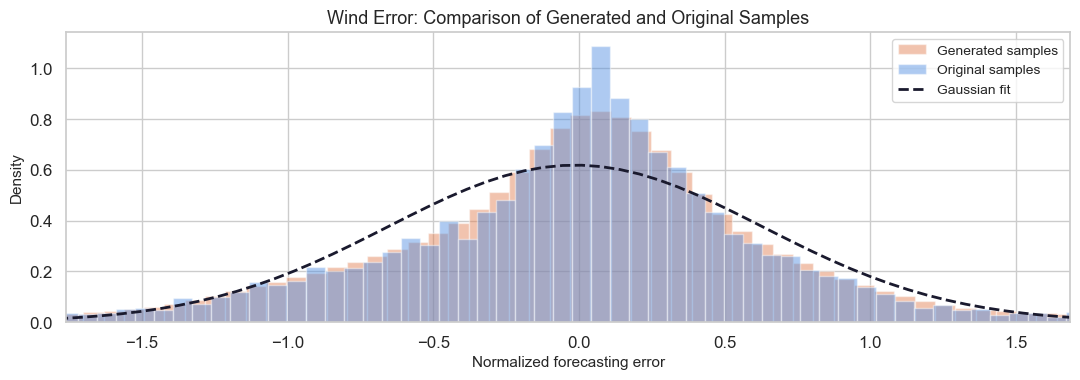

In [15]:
print("\n=== 7. Validate the generated samples ===")

# 7.1 Compare marginal distributions
sns.set_theme(style='whitegrid', font_scale=1.1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(samples_kde_corr.flatten(), bins=100, alpha=0.45,
        color='#E07B4C', label='Generated samples', density=True)
ax.hist(marginal_error, bins=100, alpha=0.45,
        color='#4C8BE0', label='Original samples', density=True)
ax.plot(x, p, color='#1A1A2E', linewidth=2.0, linestyle='--', label='Gaussian fit')
ax.set_xlim(np.percentile(marginal_error, 1), np.percentile(marginal_error, 99))
ax.set_xlabel('Normalized forecasting error', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(frameon=True, fontsize=10)
ax.set_title('Wind Error: Comparison of Generated and Original Samples', fontsize=13)
plt.tight_layout()
plt.savefig('data/wind_error_comparison.png', dpi=300, bbox_inches='tight')
print("Sample-comparison figure saved: data/wind_error_comparison.png")
plt.show()

## 8. Save results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 7.2 Compare temporal correlations
# Compute the correlation matrix of the generated data
temp_corr_gen = np.corrcoef(samples_kde_corr, rowvar=False)

# 1. Create the figure canvas with a fixed size of (16, 7)
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

# 2. Draw the first heatmap (Original samples)
axs[0].set_title('Original samples', fontsize=16, fontweight='bold', fontfamily='serif')
im0 = sns.heatmap(temp_corr, annot=False, fmt=".2f", ax=axs[0], 
                  cmap='coolwarm', square=True, cbar=False) # Keep the colormap, use square cells, and disable the default colorbar
axs[0].set_xlabel('Time', fontsize=14, fontweight='bold', fontfamily='serif')
axs[0].set_ylabel('Time', fontsize=14, fontweight='bold', fontfamily='serif')

# --- Core size-alignment logic: left colorbar ---
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.1)
plt.colorbar(axs[0].get_children()[0], cax=cax0)

# 3. Draw the second heatmap (Generated samples)
axs[1].set_title('Generated samples', fontsize=16, fontweight='bold')
im1 = sns.heatmap(temp_corr_gen, annot=False, fmt=".2f", ax=axs[1], 
                  cmap='coolwarm', square=True, cbar=False) # Keep the colormap, use square cells, and disable the default colorbar
axs[1].set_xlabel('Time', fontsize=14, fontweight='bold', fontfamily='serif')
axs[1].set_ylabel('')

# --- Core size-alignment logic: right colorbar ---
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(axs[1].get_children()[0], cax=cax1)

# 4. Adjust the layout
plt.tight_layout()

# 5. Save the figure (fixed filename and format)
plt.savefig('data/wind_error_temporal_correlation_comparison.png', dpi=300)
plt.savefig('paper/fig_wind_correlation.pdf', bbox_inches='tight')

print("Temporal-correlation comparison figure saved:")
print("  data/wind_error_temporal_correlation_comparison.png")
print("  paper/fig_wind_correlation.pdf")

plt.show()

In [ ]:
print("\n=== 8. Save results ===")

# Save the generated temporally correlated error samples for `WT_error_gen.py`
np.save('data/processed/GEFC2012_temporal_correlated_error_samples.npy', samples_kde_corr)
print(f"Error samples saved: data/processed/GEFC2012_temporal_correlated_error_samples.npy")
print(f"  Shape: {samples_kde_corr.shape}   (n_scenario, T)")

In [ ]:
# Save the normalized wind forecast prototype curve with length T
np.save('data/processed/GEFC2012_wind_forecast.npy', forecast_prototype_normalized)
print(f"Wind forecast prototype saved: data/processed/GEFC2012_wind_forecast.npy")
print(f"  Shape: {forecast_prototype_normalized.shape}   (T,)")

## Summary and usage notes

In [ ]:
print("\n=== Wind error generalization completed ===")
print(f" {n_scenario} wind error scenarios")
print(f"Each scenario contains {num_time_points} 24")
print("\n=== Usage notes ===")
print("In `WT_error_gen.py`:")
print("  1. `WT_sce_gen()` automatically loads `GEFC2012_temporal_correlated_error_samples.npy`")
print("  2. `WT_sce_gen()` automatically loads `GEFC2012_wind_forecast.npy` as the forecast prototype")
print("  3. Negative wind-generation values are clipped to zero inside `WT_sce_gen()`")
print("  4. All scenarios are normalized consistently inside `WT_sce_gen()`")